## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
import torch
import gc

### Llama 3.1: 8B
- Resource: https://huggingface.co/meta-llama/Llama-3.1-8B
- Need to login with hf account and request for access to download this package

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
!pip install -U bitsandbytes>=0.46.1

In [ ]:
%pip install -q "transformers>=4.46" accelerate bitsandbytes huggingface_hub 2>&1 | tail -2

In [ ]:
import os, time, gc
from pathlib import Path
from dataclasses import dataclass

# ── HF cache: prefer the class-shared dir on Tillicum, else default ──
# Setting HF_HOME *before* importing transformers ensures the library
# uses the shared cache for everything (hub downloads, tokenizers, ...).
_shared_cache = Path("/gpfs/projects/imt526a/huggingface")
if _shared_cache.exists():
    os.environ["HF_HOME"] = str(_shared_cache)
    HF_CACHE_DIR = str(_shared_cache)
else:
    HF_CACHE_DIR = None   # falls back to ~/.cache/huggingface

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# ── Device ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print(f"Device:    {DEVICE}")
print(f"HF cache:  {HF_CACHE_DIR or '~/.cache/huggingface (default)'}")
if DEVICE == "cuda":
    print(f"GPU:       {torch.cuda.get_device_name(0)}")
    print(f"VRAM:      {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── HF Hub auth check ────────────────────────────────────────────────────
# Unauthenticated requests are rate-limited on shared-IP environments.
# A class-wide token in /gpfs/projects/imt526a/huggingface/token would be
# picked up via HF_HOME automatically.
_hf_token = (os.environ.get("HF_TOKEN")
             or os.environ.get("HUGGING_FACE_HUB_TOKEN"))
if not _hf_token:
    for candidate in (Path(os.environ.get("HF_HOME", "")) / "token",
                      Path.home() / ".cache" / "huggingface" / "token"):
        if candidate.exists():
            _hf_token = candidate.read_text().strip()
            os.environ["HF_TOKEN"] = _hf_token
            break

print(f"HF auth:   {'token loaded' if _hf_token else 'anonymous (rate-limited)'}")

In [3]:
# # create your own hugging face token and login here
# from huggingface_hub import login
# login("your_token_from_huggingface")

- We use Llama 3.1 8B Instruct loaded with 4-bit quantization for memory-efficient inference/fine-tuning.

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────
MODEL_PRESET = "llama31"   

@dataclass
class Cfg:
    name: str
    hf_id: str
    short: str
    is_chat: bool

PRESETS = {
    "phi2": Cfg(
        "phi-2",
        "microsoft/phi-2",
        "phi2",
        is_chat=False
    ),

    "tinyllama": Cfg(
        "tinyllama",
        "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
        "tinyllama",
        is_chat=True
    ),

    "llama31": Cfg(
        "llama-3.1-8b",
        "meta-llama/Llama-3.1-8B-Instruct",
        "llama31",
        is_chat=True
    ),
}

cfg = PRESETS[MODEL_PRESET]

print(f"Primary model for §E: {cfg.name} ({cfg.hf_id})")

In [ ]:
# ── Load both SLMs in FP16 ───────────────────────────────────────────────
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
    base_mem = cuda_mem_gb()
    print(f"Baseline VRAM: {base_mem:.2f} GB")

print("Loading Llama-3.1-8B-Instruct...")
model, tokenizer = load_slm("meta-llama/Llama-3.1-8B-Instruct")
if DEVICE == "cuda":
    print(f"  VRAM after Llama-3.1-8B-Instruct:  {cuda_mem_gb():.2f} GB")

In [4]:
# model_id = "meta-llama/Llama-3.1-8B-Instruct"

# gc.collect()
# torch.cuda.empty_cache()

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.float16,
#     bnb_4bit_use_double_quant=True,
# )

# tokenizer = AutoTokenizer.from_pretrained(model_id)

# model = AutoModelForCausalLM.from_pretrained(
#     model_id,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

# model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRM

## Data Processing

### Removing symbols, website URL

In [6]:
train_df = pd.read_csv('train_data.csv')
val_df = pd.read_csv('val_data.csv')

label = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\n|\r|\t", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df['clean'] = train_df['comment_text'].apply(clean_text)
val_df['clean'] = val_df['comment_text'].apply(clean_text)


In [7]:
print(train_df.shape)

train_df.head()

(127656, 10)


,Unnamed: 0,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,clean
0,41967,6ff62abb9f08ee3d,And more unfounded personal attacks by here a...,0,0,0,0,0,0,and more unfounded personal attacks by here at...
1,155824,c438cd4e8073254a,Gilmore Girls \n\nI'm trying to figure out a f...,0,0,0,0,0,0,gilmore girls i m trying to figure out a few t...
2,17231,2d7e5045431a4c70,What is the need of tagging..when we can impro...,0,0,0,0,0,0,what is the need of tagging when we can improv...
3,82855,ddb267b1a581c366,"03:27, Jun 23, 2005 (UTC)",0,0,0,0,0,0,03 27 jun 23 2005 utc
4,31322,53252a7f4f4bf87d,Inconsistencies \n\nThis article seems to pick...,0,0,0,0,0,0,inconsistencies this article seems to pick and...


### TF-IDF

In [8]:
tfidf = TfidfVectorizer()
X_train = tfidf.fit_transform(train_df['clean'])
X_val = tfidf.transform(val_df['clean'])

#train
model = OneVsRestClassifier(LogisticRegression())
model.fit(X_train, train_df[label])

#Scores
y_pred = model.predict(X_val)
print(classification_report(val_df[label], y_pred, target_names=label))

               precision    recall  f1-score   support

        toxic       0.92      0.61      0.73      3059
 severe_toxic       0.61      0.28      0.38       311
      obscene       0.92      0.63      0.75      1710
       threat       0.55      0.11      0.19        97
       insult       0.84      0.52      0.64      1590
identity_hate       0.74      0.20      0.32       289

    micro avg       0.89      0.56      0.68      7056
    macro avg       0.76      0.39      0.50      7056
 weighted avg       0.88      0.56      0.68      7056
  samples avg       0.06      0.05      0.05      7056



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
macro_f1 = f1_score(val_df[label], y_pred, average='macro', zero_division=0)
per_label = f1_score(val_df[label], y_pred, average=None, zero_division=0)

print(f"\nMacro F1: {macro_f1:.4f}\n")
for label, score in zip(label, per_label):
    print(f"  {label:<20} {score:.4f}")


Macro F1: 0.5018

  toxic                0.7326
  severe_toxic         0.3805
  obscene              0.7490
  threat               0.1880
  insult               0.6444
  identity_hate        0.3161


### Toxic comment distribution in our dataset


Train Label Distribution
toxic
0    115421
1     12235
Name: count, dtype: int64

Validation Label Distribution
toxic
0    28856
1     3059
Name: count, dtype: int64

Train Percentages
toxic
0    90.415648
1     9.584352
Name: proportion, dtype: float64

Validation Percentages
toxic
0    90.415165
1     9.584835
Name: proportion, dtype: float64


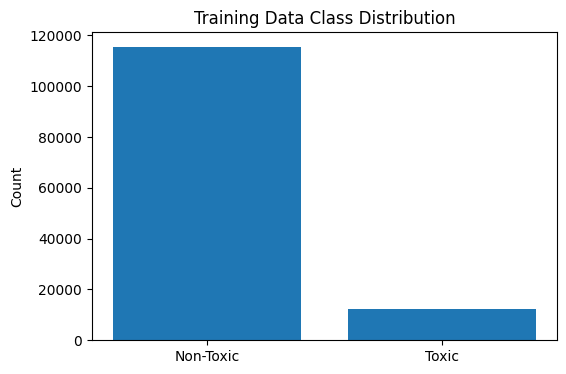

In [10]:
train_counts = train_df['toxic'].value_counts()
val_counts = val_df['toxic'].value_counts()

print("\nTrain Label Distribution")
print(train_counts)

print("\nValidation Label Distribution")
print(val_counts)

# Percentages
train_percent = train_df['toxic'].value_counts(normalize=True) * 100
val_percent = val_df['toxic'].value_counts(normalize=True) * 100

print("\nTrain Percentages")
print(train_percent)

print("\nValidation Percentages")
print(val_percent)

# Plot class imbalance
plt.figure(figsize=(6,4))
plt.bar(['Non-Toxic', 'Toxic'], train_counts.values)
plt.ylabel('Count')
plt.title('Training Data Class Distribution')
plt.show()

- Heavily imbalanced data --> may lead to more non-toxic predictions

In [11]:
# Separate toxic and non-toxic comments
non_toxic_df = train_df[train_df['toxic'] == 0]
toxic_df = train_df[train_df['toxic'] == 1]

# Sample smaller subsets for faster testing
non_toxic_sample = non_toxic_df.sample(5000, random_state=42)
toxic_sample = toxic_df.sample(5000, random_state=42, replace=True)

# Combine text
combined_text = pd.concat([
    non_toxic_sample['comment_text'],
    toxic_sample['comment_text']
])

# TF-IDF
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2)
)


### Creating Similarity Score for toxic comment

In [12]:
X = vectorizer.fit_transform(combined_text)

# Split vectors
non_toxic_vectors = X[:len(non_toxic_sample)]
toxic_vectors = X[len(non_toxic_sample):]

# Toxic centroid
# Average toxic language direction

toxic_centroid = np.asarray(toxic_vectors.mean(axis=0))

# Similarity scores
scores = cosine_similarity(non_toxic_vectors, toxic_centroid)

# Flatten
scores = scores.flatten()

# Add scores to dataframe
non_toxic_sample = non_toxic_sample.copy()
non_toxic_sample['toxicity_similarity'] = scores

# Most suspicious non-toxic examples
suspicious = non_toxic_sample.sort_values(
    by='toxicity_similarity',
    ascending=False
)

print(suspicious[['comment_text', 'toxicity_similarity']].head(20))

                                             comment_text  toxicity_similarity
78381   "\n\nThe user's final edit was to blank his Ta...             0.257130
118049  "\n\n Hey What's Up \n\nHey Pink Floyd guy,\nI...             0.252228
5675    "noobs...\nI have contested the speedy deletio...             0.236768
75771   "\n\nIsn't it what you ususally say each and e...             0.208208
56111   "\n\nThanks Ral315. I don't know what you enjo...             0.197180
116140  I dont get it.... you're clearly a bright guy....             0.197000
59947   Recent prooves of hetz being made and of the c...             0.196907
116009  this guy nailed it on the head! Paralympiakos ...             0.191037
74041   "quicker response please email me)\n\n  \nYou ...             0.189708
46112   "\n\n Life on Aisle 5 \n\nDo you have a life o...             0.188125
56962   "\n\nI thought we all discussed this that ther...             0.188000
26740   Abuse of admin privileges \n\nI have caught 

## Llama 3.1 8B Baseline

In [16]:
# tokenizer / model
tokenizer = AutoTokenizer.from_pretrained(model_id)
# define pad token for llama 3.1
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

# Use smaller subsets for speed
non_toxic_subset = non_toxic_df.sample(200, random_state=42)
toxic_subset = toxic_df.sample(200, random_state=42, replace=True)

# Embedding function
def get_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    )

    # transfer model into model.device (GPU)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.model(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1)
    # float: embedding: bfloat16
    return embedding.squeeze().detach().float().cpu().numpy()


# Toxic embeddings
print("Generating toxic embeddings...")

toxic_embeddings = np.array([
    get_embedding(text)
    for text in toxic_subset['comment_text']
])

# Toxic centroid
llama_toxic_centroid = toxic_embeddings.mean(axis=0)

# Non-toxic similarity scores
print("Checking non-toxic comments...")

similarities = []

for text in non_toxic_subset['comment_text']:
    emb = get_embedding(text)

    score = cosine_similarity(
        emb.reshape(1, -1),
        llama_toxic_centroid.reshape(1, -1)
    )[0][0]

    similarities.append(score)

non_toxic_subset = non_toxic_subset.copy()
non_toxic_subset['llama_similarity'] = similarities

# Most suspicious examples
llama_suspicious = non_toxic_subset.sort_values(
    by='llama_similarity',
    ascending=False
)

print(llama_suspicious[['comment_text', 'llama_similarity']].head(20))

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Generating toxic embeddings...
Checking non-toxic comments...
                                             comment_text  llama_similarity
11108   I propose that you mind you own business and k...          0.879795
96603   SA \n\nWhat's pimpulatin. People are reverting...          0.873099
118181  OK, Can You please also tell them, That I am s...          0.870419
38292   Notice\nStop disrupting the AFD.  You can use ...          0.862490
85004   Hello Teen, if you stop now, you lose a little...          0.855589
36126   " why don´t you block vandercken he made a""pe...          0.854810
104627  ok i will start going through all wikipedia ce...          0.850390
15782   This is Spitfire \n\nI'm a giant douche, that'...          0.841796
48863   Mrt3366 and pov \nIf you seriously think that ...          0.841683
113332  More Negative Coatrack and cruft by  \n\nTo ba...          0.839400
21621   I don't understand the vandalizing   13:35, 18...          0.835240
59947   Recent prooves of 